# India’s CPI Inflation Analysis (2014–2025)

## Introduction

This project analyzes India's Consumer Price Index (CPI) inflation rates from **2014 to 2025** using Python.

### Objectives

- Analyze annual average inflation rates.
- Identify years and months with the highest and lowest inflation.
- Examine year-to-year changes.
- Analyze the COVID-19 period.
- Study monthly inflation variability.
- Examine correlations between monthly inflation rates.
- Visualize important trends and patterns.

## 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading and Preprocessing the Dataset

The dataset is loaded from an Excel file using Pandas. The first row is skipped because the actual column headers begin from the second row. Unnecessary rows and columns are then removed to retain the relevant data for analysis.

In [2]:
# Load the Dataset
df = pd.read_excel('/content/india_cpi_inflation_2014_2025.xlsx', header=1)

# Keep only relevant rows and columns
df = df.iloc[1:13, :13]

# Assign meaningful column names
df.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert year to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Convert monthly inflation values to numeric
for col in df.columns[1:]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('*', '', regex=False),
        errors='coerce'
    )

# Display the cleaned dataset
print(df)

    Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
1   2014  8.60  7.88  8.25  8.48  8.33  6.77  7.39  7.03  5.63  4.62  3.27   
2   2015  5.19  5.37  5.25  4.87  5.01  5.40  3.69  3.74  4.41  5.00  5.41   
3   2016  5.69  5.26  4.83  5.47  5.76  5.77  6.07  5.05  4.39  4.20  3.63   
4   2017  3.17  3.65  3.89  2.99  2.18  1.46  2.36  3.28  3.28  3.58  4.88   
5   2018  5.07  4.44  4.28  4.58  4.87  4.92  4.17  3.69  3.70  3.38  2.33   
6   2019  1.97  2.57  2.86  2.99  3.05  3.18  3.15  3.28  3.99  4.62  5.54   
7   2020  7.59  6.58  5.84   NaN   NaN  6.23  6.73  6.69  7.27  7.61  6.93   
8   2021  4.06  5.03  5.52  4.23  6.30  6.26  5.59  5.30  4.35  4.48  4.91   
9   2022  6.01  6.07  6.95  7.79  7.04  7.01  6.71  7.00  7.41  6.77  5.88   
10  2023  6.52  6.44  5.66  4.70  4.31  4.87  7.44  6.83  5.02  4.87  5.55   
11  2024  5.10  5.09  4.85  4.83  4.80  5.08  3.60  3.65  5.49  6.21   NaN   
12  2025  4.26  3.61  3.34  3.16  2.82  2.10  1.61  2.07  1.44  

## 3. Exploratory Data Analysis

In [3]:
print("First 5 rows:")
print(df.head(15))

print("\nShape:")
print(df.shape)

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset Information:")
print(df.info())

print("\nData types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
    Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
1   2014  8.60  7.88  8.25  8.48  8.33  6.77  7.39  7.03  5.63  4.62  3.27   
2   2015  5.19  5.37  5.25  4.87  5.01  5.40  3.69  3.74  4.41  5.00  5.41   
3   2016  5.69  5.26  4.83  5.47  5.76  5.77  6.07  5.05  4.39  4.20  3.63   
4   2017  3.17  3.65  3.89  2.99  2.18  1.46  2.36  3.28  3.28  3.58  4.88   
5   2018  5.07  4.44  4.28  4.58  4.87  4.92  4.17  3.69  3.70  3.38  2.33   
6   2019  1.97  2.57  2.86  2.99  3.05  3.18  3.15  3.28  3.99  4.62  5.54   
7   2020  7.59  6.58  5.84   NaN   NaN  6.23  6.73  6.69  7.27  7.61  6.93   
8   2021  4.06  5.03  5.52  4.23  6.30  6.26  5.59  5.30  4.35  4.48  4.91   
9   2022  6.01  6.07  6.95  7.79  7.04  7.01  6.71  7.00  7.41  6.77  5.88   
10  2023  6.52  6.44  5.66  4.70  4.31  4.87  7.44  6.83  5.02  4.87  5.55   
11  2024  5.10  5.09  4.85  4.83  4.80  5.08  3.60  3.65  5.49  6.21   NaN   
12  2025  4.26  3.61  3.34  3.16  2.82  2.10  1.61

## 4. Annual Inflation Analysis

The annual average inflation rate is calculated for each year using the monthly inflation rates. The analysis then identifies the years with the highest and lowest annual inflation and examines year-to-year changes in inflation.

###4.1. Calculate Annual Average Inflation

In [4]:
# Calculate the annual average inflation rate from the 12 monthly values
df["Annual_Average"]=df.iloc[: ,1:].mean(axis=1)
print(df)


    Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
1   2014  8.60  7.88  8.25  8.48  8.33  6.77  7.39  7.03  5.63  4.62  3.27   
2   2015  5.19  5.37  5.25  4.87  5.01  5.40  3.69  3.74  4.41  5.00  5.41   
3   2016  5.69  5.26  4.83  5.47  5.76  5.77  6.07  5.05  4.39  4.20  3.63   
4   2017  3.17  3.65  3.89  2.99  2.18  1.46  2.36  3.28  3.28  3.58  4.88   
5   2018  5.07  4.44  4.28  4.58  4.87  4.92  4.17  3.69  3.70  3.38  2.33   
6   2019  1.97  2.57  2.86  2.99  3.05  3.18  3.15  3.28  3.99  4.62  5.54   
7   2020  7.59  6.58  5.84   NaN   NaN  6.23  6.73  6.69  7.27  7.61  6.93   
8   2021  4.06  5.03  5.52  4.23  6.30  6.26  5.59  5.30  4.35  4.48  4.91   
9   2022  6.01  6.07  6.95  7.79  7.04  7.01  6.71  7.00  7.41  6.77  5.88   
10  2023  6.52  6.44  5.66  4.70  4.31  4.87  7.44  6.83  5.02  4.87  5.55   
11  2024  5.10  5.09  4.85  4.83  4.80  5.08  3.60  3.65  5.49  6.21   NaN   
12  2025  4.26  3.61  3.34  3.16  2.82  2.10  1.61  2.07  1.44  

###4.2. Highest and Lowest Annual Inflation

In [5]:
# Identify the year with the highest annual average inflation
print("\nHighest Annual Average Inflation Rate %")
highest_annual_average = df.loc[df['Annual_Average'].idxmax(),
                                ['Year', 'Annual_Average']]
print(highest_annual_average)

# Identify the year with the lowest annual average inflation
print("\nLowest Annual Average Inflation Rate %")
lowest_annual_average= df.loc[df['Annual_Average'].idxmin(),
                              ['Year' , 'Annual_Average']]
print(lowest_annual_average)


Highest Annual Average Inflation Rate %
Year              2014.000000
Annual_Average       6.710833
Name: 1, dtype: float64

Lowest Annual Average Inflation Rate %
Year              2025.000
Annual_Average       2.225
Name: 12, dtype: float64


###4.3. Yeay-To-Year Change in Annual Average

In [6]:
# Calculate the year-to-year change in annual average inflation
Annual_change = df['Annual_Average'].diff()
print("Year-to-Year change in Average Inflation:")
print(Annual_change)

Year-to-Year change in Average Inflation:
1          NaN
2    -1.798333
3     0.048333
4    -1.633333
5     0.634167
6    -0.249167
7     2.893500
8    -1.465167
9     1.555833
10   -1.038333
11   -0.756515
12   -2.676818
Name: Annual_Average, dtype: float64


###4.4. Largest Increase and Decrease in Annual Inflation

In [7]:
# Identify the year with the largest decrease in annual inflation
largest_drop_year = df.loc[
    Annual_change.idxmin(),
    'Year'
    ]

largest_drop = Annual_change.min()

print("\nLargest Drop in Annual Inflation:")
print("Year:", largest_drop_year)
print("Drop:", largest_drop)

# Identify the year with the largest increase in annual inflation
largest_increase_year = df.loc[
    Annual_change.idxmax(),
    'Year'
]

largest_increase = Annual_change.max()

print("\nLargest Increase in Annual Inflation:")
print("Year:", largest_increase_year)
print("Change:", largest_increase)


Largest Drop in Annual Inflation:
Year: 2025
Drop: -2.676818181818182

Largest Increase in Annual Inflation:
Year: 2020
Change: 2.8934999999999986


###4.5. Annual Percentage change in Inflation

In [8]:
# Calculate percentage change in annual average inflation
df['Annual_Percentage_Change']=df['Annual_Average'].pct_change()*100

print("\nAnnual Percentage Change:")
print(df[['Year' , 'Annual_Average' , 'Annual_Percentage_Change']])


Annual Percentage Change:
    Year  Annual_Average  Annual_Percentage_Change
1   2014        6.710833                       NaN
2   2015        4.912500                -26.797467
3   2016        4.960833                  0.983885
4   2017        3.327500                -32.924576
5   2018        3.961667                 19.058352
6   2019        3.712500                 -6.289440
7   2020        6.606000                 77.939394
8   2021        5.140833                -22.179332
9   2022        6.696667                 30.264224
10  2023        5.658333                -15.505226
11  2024        4.901818                -13.369929
12  2025        2.225000                -54.608680


###4.6. Overall Average Annual Inflation

In [9]:
# Calculate the overall average annual inflation for 2014–2025
overall_average = df['Annual_Average'].mean()
print("\nOverall Annual Average Inflation:",overall_average)


Overall Annual Average Inflation: 4.901207070707071


###4.7. Years above Overall Average

In [10]:
# Identify years with inflation above the overall average
above_average_years = df[df['Annual_Average']>overall_average]

print("\nYears Above the Overall Average:")
print(above_average_years[['Year' , 'Annual_Average']])


Years Above the Overall Average:
    Year  Annual_Average
1   2014        6.710833
2   2015        4.912500
3   2016        4.960833
7   2020        6.606000
8   2021        5.140833
9   2022        6.696667
10  2023        5.658333
11  2024        4.901818


### 4.8 Annual Inflation Trend

A line graph is used to visualize the trend in India's annual average inflation rate from 2014 to 2025. It helps identify increases, decreases, and fluctuations in inflation over time.

India's Annual Average Inflation (2014–2025)


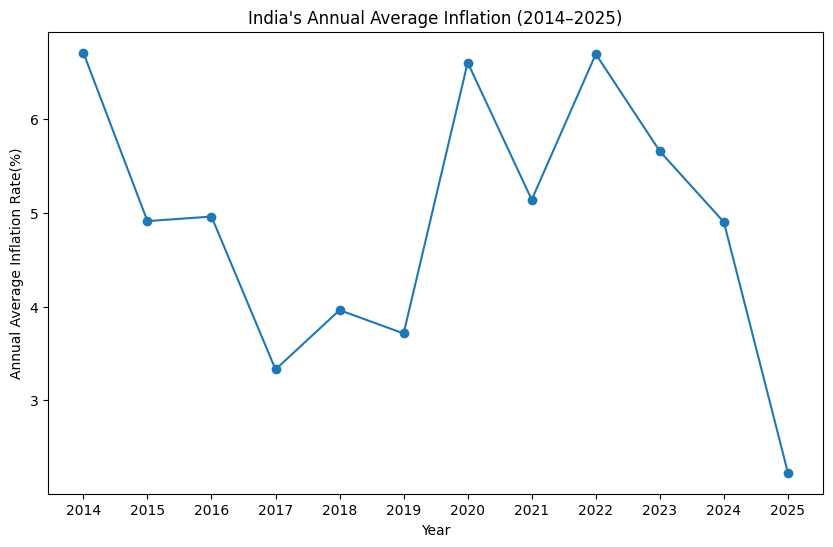

In [11]:
#Line Graph
print("India's Annual Average Inflation (2014–2025)")

plt.figure(figsize=(10, 6))
plt.plot(df['Year'],df['Annual_Average'],marker='o')
plt.xlabel('Year')
plt.xticks(df['Year'])
plt.ylabel('Annual Average Inflation Rate(%)')
plt.title('India\'s Annual Average Inflation (2014–2025)')
plt.show()

### 4.9 Annual Inflation Comparison

A bar graph is used to compare the annual average inflation rates across individual years from 2014 to 2025. It provides a clear comparison of the magnitude of inflation in each year.

India's Annual Average Inflation (2014–2025)


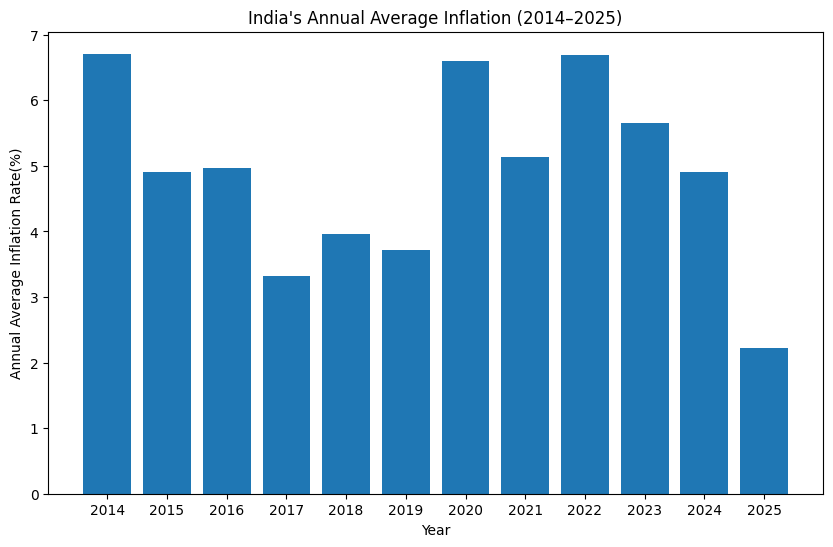

In [12]:
#Bar Graph
print("India's Annual Average Inflation (2014–2025)")

plt.figure(figsize=(10,6))
plt.bar(df['Year'],df['Annual_Average'])
plt.xlabel('Year')
plt.xticks(df['Year'])
plt.ylabel('Annual Average Inflation Rate(%)')
plt.title('India\'s Annual Average Inflation (2014–2025)')
plt.show()

## 5. Monthly Inflation Analysis

This section analyzes the average inflation rate for each month across the period 2014–2025. It identifies the months with the highest and lowest average inflation and examines the months that most frequently recorded the highest and lowest inflation within individual years.

### 5.1 Average Monthly Inflation

The average inflation rate for each month is calculated across all years from 2014 to 2025. This helps identify whether certain months generally experienced higher or lower inflation than others.

In [13]:
# Calculate the average inflation rate for each month across all years
Monthly_Average=df.iloc[:, 1:13].mean()

print("Monthly Average Inflation:")
print(Monthly_Average)

Monthly Average Inflation:
Jan    5.269167
Feb    5.165833
Mar    5.126667
Apr    4.917273
May    4.951818
Jun    4.920833
Jul    4.875833
Aug    4.800833
Sep    4.698333
Oct    4.632500
Nov    4.458182
Dec    4.681667
dtype: float64


### 5.2 Highest and Lowest Average Inflation Months

The months with the highest and lowest average inflation rates across the 2014–2025 period are identified using the maximum and minimum values of the Monthly_Average series.

In [14]:
print("Highest Monthly Average Inflation:")

highest_monthly_average_inflation = Monthly_Average.idxmax()
print("\nMonth: ",highest_monthly_average_inflation)

highest_monthly_average_inflation = Monthly_Average.max()
print("\nInflation Rate %: ",highest_monthly_average_inflation)

print("\nLowest Monthly Average Inflation")
lowest_monthly_average_inflation = Monthly_Average.idxmin()
print("\nMonth: ",lowest_monthly_average_inflation)

lowest_monthly_average_inflation = Monthly_Average.min()
print("\nInflation Rate %: ",lowest_monthly_average_inflation)

Highest Monthly Average Inflation:

Month:  Jan

Inflation Rate %:  5.269166666666666

Lowest Monthly Average Inflation

Month:  Nov

Inflation Rate %:  4.458181818181818


### 5.3 Average Monthly Inflation Visualization

A bar graph is used to compare the average inflation rates across the twelve months from January to December.

Average Monthly Inflation in India (2014–2025)


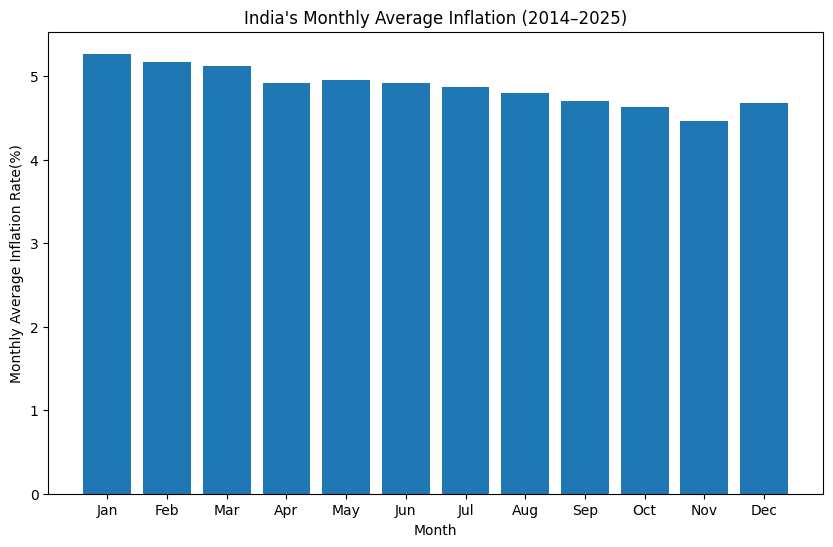

In [15]:
print("Average Monthly Inflation in India (2014–2025)")

plt.figure(figsize=(10,6))
plt.bar(Monthly_Average.index,Monthly_Average.values)
plt.xlabel('Month')
plt.xticks(Monthly_Average.index)
plt.ylabel('Monthly Average Inflation Rate(%)')
plt.title('India\'s Monthly Average Inflation (2014–2025)')
plt.show()

### 5.4 Highest-Inflation Month in Each Year

The month with the highest inflation rate is identified for each year by comparing the twelve monthly inflation values within that year.

In [16]:
Highest_Inflation_Month=df.iloc[:, 1:13].idxmax(axis=1)
print(Highest_Inflation_Month)

yearly_peak_month=pd.DataFrame({
    'Year' : df['Year'],
    'Highest Inflation Month' : Highest_Inflation_Month
})
print(yearly_peak_month)


1     Jan
2     Dec
3     Jul
4     Dec
5     Jan
6     Dec
7     Oct
8     May
9     Apr
10    Jul
11    Oct
12    Jan
dtype: object
    Year Highest Inflation Month
1   2014                     Jan
2   2015                     Dec
3   2016                     Jul
4   2017                     Dec
5   2018                     Jan
6   2019                     Dec
7   2020                     Oct
8   2021                     May
9   2022                     Apr
10  2023                     Jul
11  2024                     Oct
12  2025                     Jan


### 5.5 Most Frequent Highest-Inflation Month

The frequency of each month appearing as the highest-inflation month is calculated to determine which months most frequently recorded the highest inflation across the years.

In [17]:
print("Frequenct of Highest Inflation Month:\n")

print(yearly_peak_month['Highest Inflation Month'].value_counts())

Frequenct of Highest Inflation Month:

Highest Inflation Month
Jan    3
Dec    3
Jul    2
Oct    2
May    1
Apr    1
Name: count, dtype: int64


### 5.6 Lowest-Inflation Month in Each Year

The month with the lowest inflation rate is identified for each year by comparing the twelve monthly inflation values within that year.

In [18]:
Lowest_Inflation_Month=df.iloc[:, 1:13].idxmin(axis=1)
print(Lowest_Inflation_Month)

yearly_low_month = pd.DataFrame({
    'Year' : df['Year'],
    'Lowest Inflation Month' : Lowest_Inflation_Month
})
print(yearly_low_month)


1     Nov
2     Jul
3     Dec
4     Jun
5     Dec
6     Jan
7     Dec
8     Jan
9     Dec
10    May
11    Jul
12    Oct
dtype: object
    Year Lowest Inflation Month
1   2014                    Nov
2   2015                    Jul
3   2016                    Dec
4   2017                    Jun
5   2018                    Dec
6   2019                    Jan
7   2020                    Dec
8   2021                    Jan
9   2022                    Dec
10  2023                    May
11  2024                    Jul
12  2025                    Oct


### 5.7 Most Frequent Lowest-Inflation Month

The frequency of each month appearing as the lowest-inflation month is calculated to identify which months most frequently recorded the lowest inflation across the years.

In [19]:
print("Frequency of Lowest Inflation Month:\n")

print(yearly_low_month['Lowest Inflation Month'].value_counts())

Frequency of Lowest Inflation Month:

Lowest Inflation Month
Dec    4
Jul    2
Jan    2
Nov    1
Jun    1
May    1
Oct    1
Name: count, dtype: int64


## 6. COVID-19 Period Analysis

This section examines India's annual average inflation during the COVID-19 period. The years 2019–2021 are considered to observe the change in inflation before, during, and after the major disruption caused by the pandemic.

### 6.1 Inflation During the COVID-19 Period

The annual average inflation values for 2019, 2020, and 2021 are extracted to examine the changes during the COVID-19 period.

In [20]:
covid_years_avrerage=covid_years = df[
    df['Year'].isin([2019, 2020, 2021])
    ]

print(covid_years[['Year', 'Annual_Average']])

   Year  Annual_Average
6  2019        3.712500
7  2020        6.606000
8  2021        5.140833


### 6.2 Year-to-Year Change During COVID-19

The year-to-year change in annual average inflation is calculated for the selected COVID-19 period to identify the increase or decrease in inflation.

In [21]:
# Calculate year-to-year change during the COVID-19 period
covid_inflation_change =covid_years['Annual_Average'].diff()

print("Year-to-Year Change During COVID-19:")
print(covid_inflation_change)

Year-to-Year Change During COVID-19:
6         NaN
7    2.893500
8   -1.465167
Name: Annual_Average, dtype: float64


### 6.3 COVID-19 Inflation Comparison

A bar graph is used to compare the annual average inflation rates during 2019–2021 and visualize the change in inflation during the COVID-19 period.

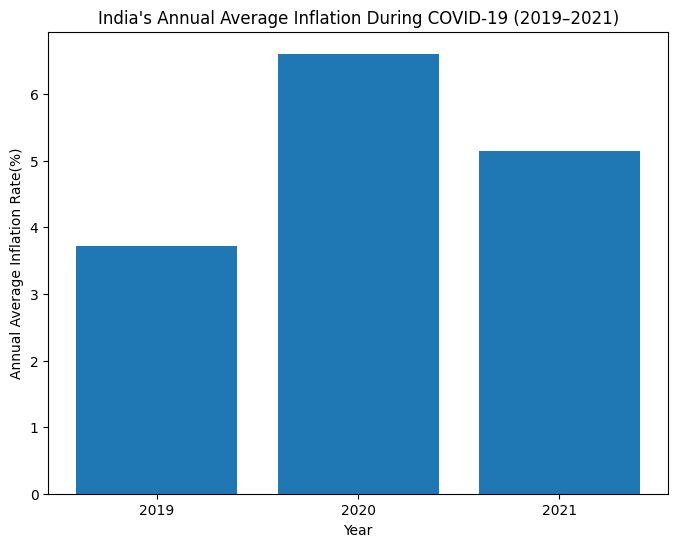

In [22]:
plt.figure(figsize=(8,6))

plt.bar(
    covid_years['Year'],
    covid_years['Annual_Average']
    )

plt.xlabel('Year')
plt.xticks(covid_years['Year'])
plt.ylabel('Annual Average Inflation Rate(%)')
plt.title('India\'s Annual Average Inflation During COVID-19 (2019–2021)')
plt.show()

## 7. Monthly Inflation Variability

This section examines the variation in monthly inflation rates within each year. Standard deviation is used to measure how much the monthly inflation values fluctuate around their yearly average.

### 7.1 Monthly Standard Deviation

The standard deviation of the twelve monthly inflation rates is calculated for each year. A higher standard deviation indicates greater variation in monthly inflation, while a lower value indicates more consistent monthly inflation.

In [23]:
# Calculate the standard deviation of monthly inflation for each year
df['Monthly_Std'] = df.iloc[:, 1:13].std(axis=1)

print("Monthly Standard Deviation:")
print(df[['Year', 'Monthly_Std']])

Monthly Standard Deviation:
    Year  Monthly_Std
1   2014     1.831822
2   2015     0.640499
3   2016     0.879571
4   2017     1.058379
5   2018     0.967629
6   2019     1.485935
7   2020     0.902936
8   2021     0.760508
9   2022     0.644351
10  2023     0.967667
11  2024     0.744645
12  2025     1.227040


### 7.2 Highest and Lowest Monthly Variability

The years with the highest and lowest monthly standard deviation are identified to determine the years with the greatest and least fluctuation in monthly inflation.

In [24]:
# Find the year with the highest monthly variability
highest_variability = df.loc[
    df['Monthly_Std'].idxmax(),
    ['Year', 'Monthly_Std']
]

print("Highest Monthly Variability:")
print(highest_variability)

# Find the year with the lowest monthly variability
lowest_variability = df.loc[
    df['Monthly_Std'].idxmin(),
    ['Year', 'Monthly_Std']
]

print("\nLowest Monthly Variability:")
print(lowest_variability)

Highest Monthly Variability:
Year           2014.000000
Monthly_Std       1.831822
Name: 1, dtype: float64

Lowest Monthly Variability:
Year           2015.000000
Monthly_Std       0.640499
Name: 2, dtype: float64


### 7.3 Monthly Inflation Variability Over Time

A line graph is used to visualize how the variability of monthly inflation changed from 2014 to 2025.

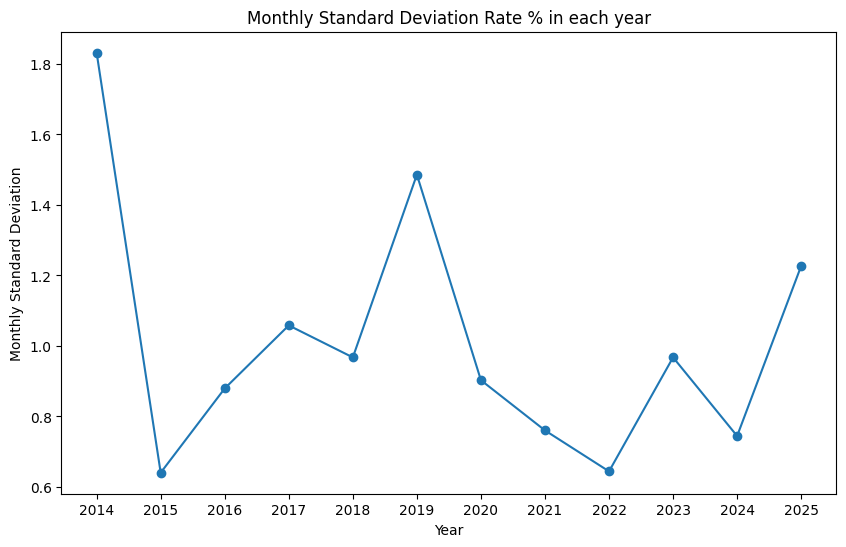

In [25]:
plt.figure(figsize=(10,6))

plt.plot(
    df['Year'],
    df['Monthly_Std'],marker='o'
    )

plt.xlabel('Year')
plt.xticks(df['Year'])
plt.ylabel('Monthly Standard Deviation')
plt.title('Monthly Standard Deviation Rate % in each year')
plt.show()

## 8. Relationship Between Monthly Inflation Rates

This section examines the relationship between inflation rates in different months. A scatter plot is used to compare January and December inflation rates, followed by correlation analysis to measure the strength and direction of relationships between all monthly inflation rates.

### 8.1 Relationship Between January and December Inflation

A scatter plot is used to examine the relationship between January and December inflation rates across the years. The correlation coefficient is also calculated to measure the strength and direction of this relationship.

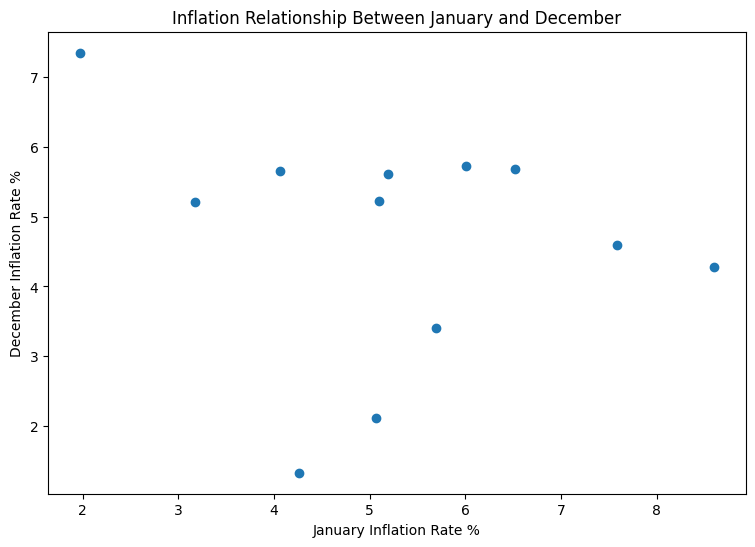


Correlation between January and December inflation:
-0.21941276995507908


In [26]:
plt.figure(figsize=(9,6))

plt.scatter(df['Jan'],df['Dec'])
plt.xlabel('January Inflation Rate %')
plt.ylabel('December Inflation Rate %')
plt.title("Inflation Relationship Between January and December")
plt.show()

# Calculate the correlation between January and December inflation
correlation = df['Jan'].corr(df['Dec'])

print("\nCorrelation between January and December inflation:")
print(correlation)

### 8.2 Correlation Between Monthly Inflation Rates

A correlation matrix is calculated to measure the relationship between the inflation rates of every pair of months. Correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate a weak relationship.

In [27]:
monthly_correlation = df.iloc[:, 1:13].corr()

print("Correlation Matrix of Monthly Inflation Rates:")
print(monthly_correlation)

Correlation Matrix of Monthly Inflation Rates:
          Jan       Feb       Mar       Apr       May       Jun       Jul  \
Jan  1.000000  0.955533  0.848436  0.856959  0.766923  0.701849  0.777345   
Feb  0.955533  1.000000  0.942899  0.868935  0.828449  0.787374  0.856996   
Mar  0.848436  0.942899  1.000000  0.928203  0.897920  0.813779  0.821472   
Apr  0.856959  0.868935  0.928203  1.000000  0.911236  0.823955  0.768788   
May  0.766923  0.828449  0.897920  0.911236  1.000000  0.944335  0.793678   
Jun  0.701849  0.787374  0.813779  0.823955  0.944335  1.000000  0.824989   
Jul  0.777345  0.856996  0.821472  0.768788  0.793678  0.824989  1.000000   
Aug  0.768490  0.863104  0.861855  0.799626  0.775564  0.781862  0.973030   
Sep  0.617534  0.699311  0.718416  0.780785  0.715054  0.779255  0.754488   
Oct  0.411143  0.520011  0.520164  0.523847  0.505924  0.659879  0.597434   
Nov  0.086468  0.249060  0.257555  0.111810  0.108218  0.341473  0.427095   
Dec -0.219413  0.009291  0.11

### 8.3 Monthly Inflation Correlation Heatmap

A heatmap is used to visualize the correlation matrix. The color intensity makes it easier to identify strong positive, weak, and negative relationships between monthly inflation rates.

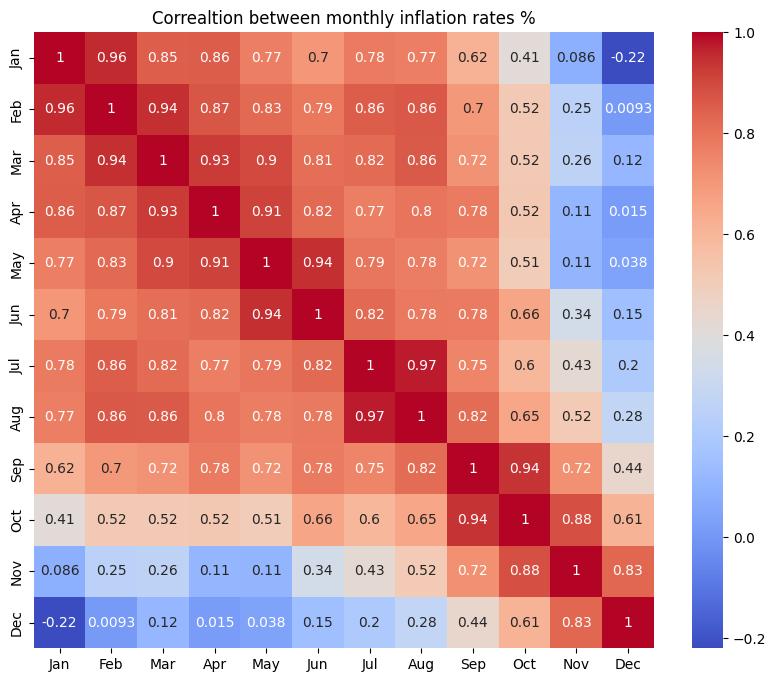

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(
    monthly_correlation ,
    annot=True ,
    cmap='coolwarm'
    )

plt.title('Correaltion between monthly inflation rates %')
plt.show()

## 9. Key Findings

The analysis of India's CPI inflation from 2014 to 2025 revealed several important patterns and trends in annual and monthly inflation.

### Key Observations

- **2014 recorded the highest annual average inflation** during the study period.
- **2025 recorded the lowest annual average inflation** during the study period.
- Inflation showed considerable fluctuations across the years, with periods of both increases and decreases.
- The **largest year-to-year increase** in annual average inflation occurred between **2019 and 2020**.
- **January had the highest average monthly inflation**, while **November had the lowest average monthly inflation** across the study period.
- **2014 had the highest monthly inflation variability**, while **2015 had the lowest**, based on monthly standard deviation.
- During the **2019–2021 COVID-19 period**, annual inflation changed considerably, with a notable increase in 2020.
- The strongest monthly correlation was observed between **July and August**, with a correlation of approximately **0.97**.
- **January and December** showed a weak negative correlation of approximately **−0.22**.
- Several consecutive months showed strong positive correlations, indicating that inflation rates in nearby months often moved in a similar direction.

## 10. Conclusion

The analysis of India's CPI inflation from 2014 to 2025 shows that inflation experienced significant fluctuations over the study period. The annual analysis identified substantial differences between years, with 2014 recording the highest annual average inflation and 2025 recording the lowest.

The monthly analysis showed that inflation varied across different months, with January having the highest average monthly inflation and November having the lowest. The standard deviation analysis also showed that the degree of monthly fluctuation differed across years.

The COVID-19 period analysis revealed a notable change in annual inflation, particularly between 2019 and 2020. Furthermore, the correlation analysis showed strong positive relationships between several consecutive months, indicating that monthly inflation rates often moved together.

Overall, the project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to clean, analyze, visualize, and interpret real-world inflation data and identify meaningful trends and relationships.